In [ ]:
# Install kaggle
!pip install kaggle

# Upload kaggle.json
from google.colab import files
files.upload()

: 

In [2]:
# Setup kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
# Download dataset
!kaggle datasets download -d phucthaiv02/butterfly-image-classification

Dataset URL: https://www.kaggle.com/datasets/phucthaiv02/butterfly-image-classification
License(s): CC0-1.0
100% 226M/226M [00:15<00:00, 15.2MB/s]



In [4]:
# Extract dataset
import zipfile

with zipfile.ZipFile("butterfly-image-classification.zip", 'r') as zip_ref:
    zip_ref.extractall("/content")

In [5]:

import os
os.listdir('/content')

['.config',
 'Training_set.csv',
 'train',
 'test',
 'kaggle.json',
 'butterfly-image-classification.zip',
 'Testing_set.csv',
 'sample_data']

In [6]:
train_dir = "/content/train"
test_dir = "/content/test"

Found 5200 validated image filenames belonging to 75 classes.
Found 1299 validated image filenames belonging to 75 classes.
Found 2786 validated image filenames.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 534ms/step - accuracy: 0.2888 - loss: 3.0897 - val_accuracy: 0.6520 - val_loss: 1.6231
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 334ms/step - accuracy: 0.5750 - loss: 1.6102 - val_accuracy: 0.7621 - val_loss: 0.9750
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 335ms/step - accuracy: 0.6638 - loss: 1.2197 - val_accuracy: 0.7937 - val_loss: 0.7938
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 333ms/step - accuracy: 0.7142 - loss: 1.0231 - val_accuracy: 0.8060 - val_loss: 0.7220
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 337ms/step - accuracy: 0.7258 - loss: 0.9252 - val_accuracy: 0.8106 - val_loss: 0.6985
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 330ms/step - accuracy: 0.7640 - loss: 0.7841 - val_accuracy: 0.8152 - val_loss: 0.6376
Ep

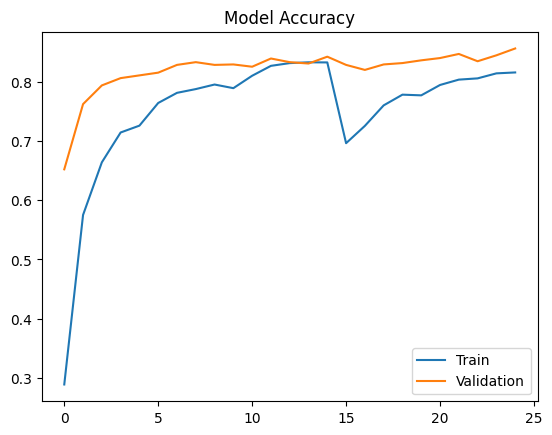

88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 191ms/step
✅ Submission file saved!


In [7]:
# 1. IMPORT LIBRARIES
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


# 2. LOAD CSV FILES
train_df = pd.read_csv('/content/Training_set.csv')
test_df = pd.read_csv('/content/Testing_set.csv')

# Correct paths
train_df['filename'] = train_df['filename'].apply(lambda x: os.path.join('/content/train', x))
test_df['filename'] = test_df['filename'].apply(lambda x: os.path.join('/content/test', x))

# 3. DATA GENERATOR (AUGMENTED)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

train_data = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='label',
    target_size=(160,160),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='label',
    target_size=(160,160),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col=None,
    target_size=(160,160),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

# 4. MODEL (TRANSFER LEARNING)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

num_classes = len(train_data.class_indices)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# 5. COMPILE
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. INITIAL TRAINING
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

# 7. FINE-TUNING
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# 8. EVALUATE
loss, accuracy = model.evaluate(val_data)
print("Validation Accuracy:", accuracy)

# 9. PLOT
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'])
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Model Accuracy')
plt.show()

# 10. PREDICT
predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)

class_indices = train_data.class_indices
labels_map = dict((v,k) for k,v in class_indices.items())

predicted_labels = [labels_map[k] for k in predicted_classes]

# 11. SAVE SUBMISSION
submission = pd.DataFrame({
    'filename': test_df['filename'].apply(lambda x: x.split('/')[-1]),
    'label': predicted_labels
})

submission.to_csv('/content/submission.csv', index=False)

print("✅ Submission file saved!")

In [9]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image

# Class names
class_names = list(train_data.class_indices.keys())

def predict(img):
    img = img.resize((160,160))
    img_array = np.array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    idx = np.argmax(prediction)
    confidence = prediction[0][idx] * 100

    return f"🦋 {class_names[idx]} ({confidence:.2f}%)"

# Create interface
app = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs="text",
    title="🦋 Butterfly Classifier"
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://301db4e0c148d98135.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
